<a href="https://colab.research.google.com/github/tetu-jpg/Superstore/blob/main/Sample_Superstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/tetu-jpg/Superstore/main/Sample%20-%20Superstore.csv"
store= pd.read_csv(url, encoding="latin1")

In [13]:
#to see the first 5 rows from the dataset
store.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
#to see the data structure and types
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
#summary statics of the dataset
store.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [16]:
#identifying missing values
store.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [17]:
#dataset size
store.shape

(9994, 21)

In [18]:
#dataset columns
store.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [19]:
#handling missing values
store=store.dropna()

In [20]:
#convert to datetime
store["Order Date"]=pd.to_datetime(store["Order Date"])

In [21]:
#extract month and year
store["Month"]=store["Order Date"].dt.month

In [22]:
store["Year"]=store["Order Date"].dt.year

In [23]:
#creating new column called total sales
store["Total Sales"]=store["Sales"]*store["Quantity"]

In [24]:
#verfiying my new column
store[["Sales","Quantity","Total Sales"]]

,Sales,Quantity,Total Sales
0,261.9600,2,523.9200
1,731.9400,3,2195.8200
2,14.6200,2,29.2400
3,957.5775,5,4787.8875
4,22.3680,2,44.7360
...,...,...,...
9989,25.2480,3,75.7440
9990,91.9600,2,183.9200
9991,258.5760,2,517.1520
9992,29.6000,4,118.4000


In [25]:
#groupby technique
#total sales category
sale_category = store.groupby('Category')['Sales'].sum()

In [26]:
#total profit by region
region_profit=store.groupby("Region")["Profit"].sum()

In [27]:
#top 5 customesrs by sales
top_customers=store.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(5)

In [28]:
#monthly sales trend
month_sale=store.groupby(["Year","Month"])["Sales"].sum()

In [29]:
#pivot tables of sales by category and region
pd.pivot_table(
store,
values="Sales",
index="Category",
columns="Region",
aggfunc="sum"


)

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


In [30]:
#sales trends by segment over time
pd.pivot_table(
store,
values="Sales",
index="Segment",
columns="Month",
aggfunc="sum"
)

Month,1,2,3,4,5,6,7,8,9,10,11,12
Segment,,,,,,,,,,,,
Consumer,50441.2906,33826.1760,89174.7070,54845.1895,86932.7144,82910.1803,81769.773,82319.8063,185055.9196,66713.0877,170958.7383,176453.7623
Corporate,26790.3480,14575.0670,58239.9132,49233.1636,47289.0323,40858.5370,46919.206,57529.4477,74020.2213,78291.7600,119431.3957,92968.2750
Home Office,17693.1970,11350.0084,57590.8686,33683.7755,20807.0650,28949.9620,18549.118,19194.8090,48573.8048,55318.1370,62070.9370,55871.4662


In [31]:
#profit of sub-category
pd.pivot_table(
store,
values="Profit",
index="Sub-Category",
aggfunc="sum"
)

,Profit
Sub-Category,
Accessories,41936.6357
Appliances,18138.0054
Art,6527.7870
Binders,30221.7633
Bookcases,-3472.5560
Chairs,26590.1663
Copiers,55617.8249
Envelopes,6964.1767
Fasteners,949.5182


In [32]:
#splitting dataset into dataframes
Orders=store[["Order ID","Customer Name","Order Date"]]
Sales=store[["Order ID","Category","Sales","Profit"]]

In [33]:
#merging the data frames
merged=pd.merge(
Orders,
Sales,
on="Order ID",
how="inner"
)

In [34]:
#displaying the first 5 rows of merged dataframe
merged.head()

,Order ID,Customer Name,Order Date,Category,Sales,Profit
0,CA-2016-152156,Claire Gute,2016-11-08,Furniture,261.96,41.9136
1,CA-2016-152156,Claire Gute,2016-11-08,Furniture,731.94,219.5820
2,CA-2016-152156,Claire Gute,2016-11-08,Furniture,261.96,41.9136
3,CA-2016-152156,Claire Gute,2016-11-08,Furniture,731.94,219.5820
4,CA-2016-138688,Darrin Van Huff,2016-06-12,Office Supplies,14.62,6.8714


In [35]:
#size of the new dataframe
merged.shape

(29906, 6)

In [36]:
import matplotlib.pyplot as plt

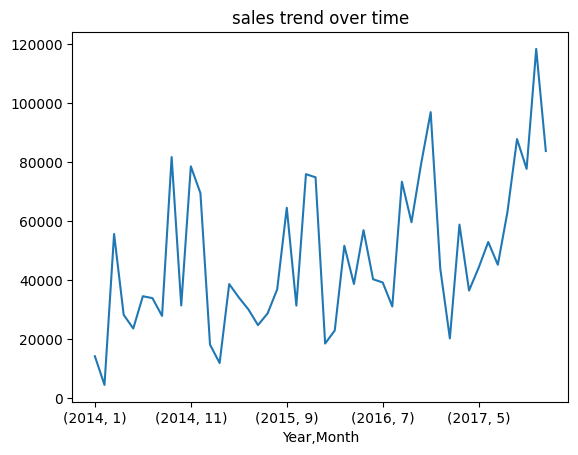

In [37]:
# line chart sales trend over time
month_sale.plot(kind="line")
plt.title("sales trend over time")
plt.show()

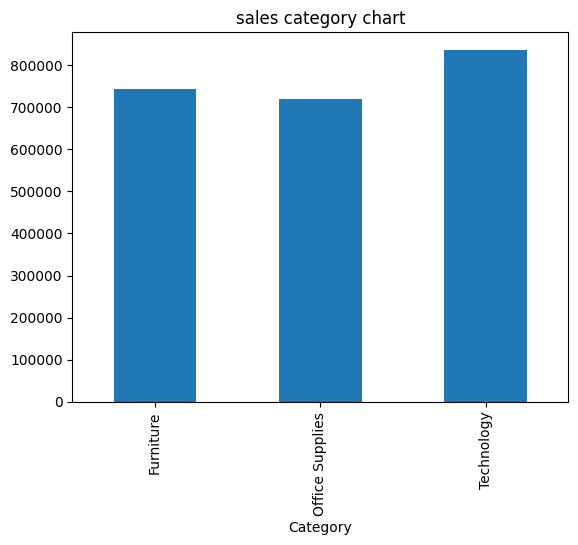

In [38]:
#bar chart of sales by category
sale_category.plot(kind="bar")
plt.title("sales category chart")
plt.show()

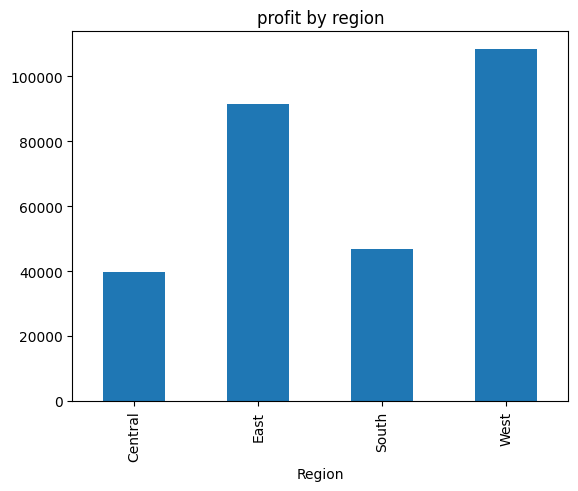

In [39]:
region_profit.plot(kind="bar")
plt.title("profit by region")
plt.show()

In [40]:
#segment distribution
segments=store["Segment"].value_counts()

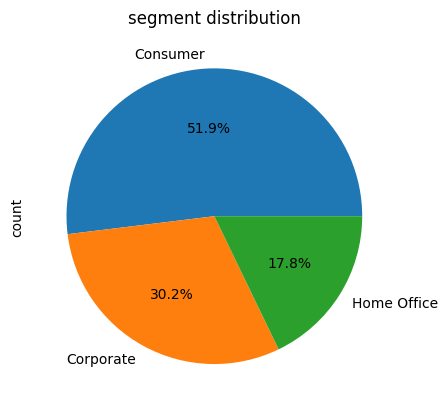

In [41]:
segments.plot(kind="pie",autopct="%1.1f%%")
plt.title("segment distribution")
plt.show()

In [42]:
#insights

In [43]:
#most profitable category
# shows the most profitable category from the dataset by using the groupby technique
store.groupby("Category")["Profit"].sum().idxmax()

'Technology'

In [44]:
#least performing region
#shows the least performing region that has less profit from others in the dataset
store.groupby("Region")["Profit"].sum().idxmin()

'Central'

In [45]:
#relationship between sales and profit
store[["Sales","Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.479064
Profit,0.479064,1.000000


In [48]:
#the monthly trend of category,sales and profit
store.groupby(["Year","Month"])[["Category","Sales","Profit"]].sum()

Category        Sales  \
Year Month                                                                   
2014 1      Office SuppliesTechnologyFurnitureOffice Suppl...   14236.8950   
     2      FurnitureTechnologyTechnologyOffice SuppliesOf...    4519.8920   
     3      FurnitureOffice SuppliesOffice SuppliesOffice ...   55691.0090   
     4      Office SuppliesOffice SuppliesOffice SuppliesT...   28295.3450   
     5      Office SuppliesTechnologyTechnologyFurnitureOf...   23648.2870   
     6      FurnitureOffice SuppliesTechnologyOffice Suppl...   34595.1276   
     7      Office SuppliesFurnitureOffice SuppliesTechnol...   33946.3930   
     8      Office SuppliesTechnologyOffice SuppliesOffice...   27909.4685   
     9      FurnitureOffice SuppliesTechnologyOffice Suppl...   81777.3508   
     10     Office SuppliesOffice SuppliesOffice SuppliesF...   31453.3930   
     11     Office SuppliesFurnitureTechnologyTechnologyTe...   78628.7167   
     12     Office SuppliesTechnologyFurnitureOffice Suppl...   69545.6205   
2015 1      Office SuppliesFurnitureOffice SuppliesOffice ...   18174.0756   
     2      TechnologyFurnitureFurnitureTechnologyFurnitur...   11951.4110   
     3      FurnitureOffice SuppliesOffice SuppliesOffice ...   38726.2520   
     4      Office SuppliesOffice SuppliesFurnitureFurnitu...   34195.2085   
     5      Office SuppliesOffice SuppliesOffice SuppliesO...   30131.6865   
     6      Office SuppliesTechnologyOffice SuppliesOffice...   24797.2920   
     7      TechnologyFurnitureOffice SuppliesFurnitureOff...   28765.3250   
     8      Office SuppliesFurnitureOffice SuppliesOffice ...   36898.3322   
     9      FurnitureFurnitureOffice SuppliesFurnitureOffi...   64595.9180   
     10     FurnitureOffice SuppliesTechnologyFurnitureTec...   31404.9235   
     11     Office SuppliesOffice SuppliesTechnologyOffice...   75972.5635   
     12     Office SuppliesFurnitureFurnitureTechnologyTec...   74919.5212   
2016 1      Office SuppliesTechnologyOffice SuppliesTechno...   18542.4910   
     2      Office SuppliesFurnitureOffice SuppliesOffice ...   22978.8150   
     3      TechnologyOffice SuppliesOffice SuppliesTechno...   51715.8750   
     4      Office SuppliesOffice SuppliesTechnologyTechno...   38750.0390   
     5      Office SuppliesTechnologyOffice SuppliesOffice...   56987.7280   
     6      Office SuppliesTechnologyTechnologyOffice Supp...   40344.5340   
     7      Office SuppliesOffice SuppliesOffice SuppliesT...   39261.9630   
     8      Office SuppliesTechnologyOffice SuppliesTechno...   31115.3743   
     9      Office SuppliesOffice SuppliesTechnologyOffice...   73410.0249   
     10     Office SuppliesOffice SuppliesOffice SuppliesO...   59687.7450   
     11     FurnitureFurnitureOffice SuppliesOffice Suppli...   79411.9658   
     12     Office SuppliesOffice SuppliesOffice SuppliesT...   96999.0430   
2017 1      FurnitureTechnologyOffice SuppliesOffice Suppl...   43971.3740   
     2      TechnologyOffice SuppliesOffice SuppliesFurnit...   20301.1334   
     3      Office SuppliesOffice SuppliesOffice SuppliesO...   58872.3528   
     4      Office SuppliesOffice SuppliesFurnitureFurnitu...   36521.5361   
     5      FurnitureOffice SuppliesOffice SuppliesOffice ...   44261.1102   
     6      Office SuppliesOffice SuppliesFurnitureOffice ...   52981.7257   
     7      FurnitureOffice SuppliesOffice SuppliesOffice ...   45264.4160   
     8      FurnitureFurnitureFurnitureFurnitureOffice Sup...   63120.8880   
     9      TechnologyOffice SuppliesOffice SuppliesOffice...   87866.6520   
     10     Office SuppliesTechnologyOffice SuppliesOffice...   77776.9232   
     11     Office SuppliesOffice SuppliesFurnitureTechnol...  118447.8250   
     12     Office SuppliesFurnitureOffice SuppliesFurnitu...   83829.3188   

                Profit  
Year Month              
2014 1       2450.1907  
     2        862.3084  
     3        498.7299  
     4       3488.8352  
  